In [1]:
from dataclasses import dataclass
from typing import Any, Dict, Optional, Sequence, Tuple

import h5py
import numpy as np
from torch.utils.data import Dataset, DataLoader
import bisect

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
@dataclass(frozen=True)
class PatchSpec:
    patch_wdh: Tuple[int, int, int]   # (W, D, H)
    stride_wdh: Tuple[int, int, int]  # (sW, sD, sH)


class H5PatchDataset(Dataset):
    """
    Loads 3D patches from a single HDF5 dataset.

    Assumptions:
      - HDF5 dataset stored as (H, D, W)  (i.e. z,y,x-ish but named here H,D,W)
      - you specify patch/stride as (W, D, H)
      - only full patches (drops borders)
    Returns:
      - patch as float32 with shape [C, D, H, W] (C=1 by default)
      - out_dict with optional class label "y"
    """
    def __init__(
        self,
        h5_path: str,
        dset_key: str,
        spec: PatchSpec,
        classes: Optional[Sequence[int]] = None,
        add_channel: bool = True,
    ):
        super().__init__()
        self.h5_path = h5_path
        self.dset_key = dset_key
        self.spec = spec
        self.add_channel = add_channel

        # read shape once
        with h5py.File(self.h5_path, "r") as f:
            H, D, W = f[self.dset_key].shape  # (H, D, W)

        pw, pd, ph = spec.patch_wdh
        sw, sd, sh = spec.stride_wdh

        # compute all patch starts (drop borders)
        ws = range(0, W - pw + 1, sw)
        ds = range(0, D - pd + 1, sd)
        hs = range(0, H - ph + 1, sh)

        self.starts_wdh = [(w, d, h) for h in hs for d in ds for w in ws]  # flat list

        self.classes = None
        if classes is not None:
            if len(classes) != len(self.starts_wdh):
                raise ValueError(f"classes must have length {len(self.starts_wdh)}, got {len(classes)}")
            self.classes = np.asarray(classes, dtype=np.int64)

    def __len__(self) -> int:
        return len(self.starts_wdh)

    def __getitem__(self, idx: int):
        w0, d0, h0 = self.starts_wdh[idx]
        pw, pd, ph = self.spec.patch_wdh

        # HDF5 order is (H, D, W) -> slices are (h, d, w)
        with h5py.File(self.h5_path, "r") as f:
            vol = f[self.dset_key]
            patch = vol[h0 : h0 + ph, d0 : d0 + pd, w0 : w0 + pw]

        x = np.asarray(patch, dtype=np.float32)


        # return [C, D, H, W]
        # currently x is [H, D, W] for the patch -> transpose to [D, H, W]
        x = np.transpose(x, (1, 0, 2))  # (D, H, W)
        if self.add_channel:
            x = x[None, ...]            # (1, D, H, W)

        out: Dict[str, Any] = {"start_wdh": np.array([w0, d0, h0], dtype=np.int64)}
        if self.classes is not None:
            out["y"] = np.array(self.classes[idx], dtype=np.int64)

        return x, out

In [3]:
file_path = Path("/Volumes/CT-Data/CT_Hys/EPP_2020-12-09.train.h5")

In [4]:
spec = PatchSpec(patch_wdh=(64,)*3, stride_wdh=(32,)*3)
ds = H5PatchDataset(file_path, "volume", spec)
x, meta = ds[0]  # x: [1, D, H, W]

torch.Size([8, 1, 64, 64, 64])
torch.float32


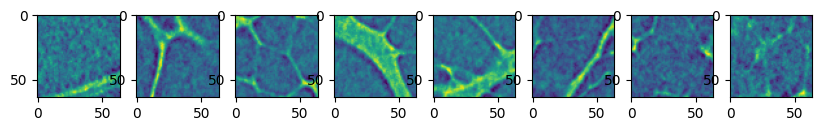

In [5]:
loader = DataLoader(
    ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,      # set 0 on Windows / if you hit HDF5 multiprocessing issues
    # pin_memory=True,
    drop_last=True,
    # persistent_workers=True,
)

# example
for x, meta in loader:
    print(x.shape)    # x: [B, 1, D, H, W]
    # meta["start_wdh"]: [B, 3]

    print(x.dtype)

    fig, ax = plt.subplots(1,8,figsize = (10,4))

    for i in range(x.shape[0]):
        ax[i].imshow(x[i,0,0,::])
       

    break


In [2]:
from improved_diffusion.hdf5_dataset import estimate_u16_clip_bounds, PatchSpec, MultiH5PatchDataset

In [3]:
from mpi4py import MPI
rank = MPI.COMM_WORLD.Get_rank()
world = MPI.COMM_WORLD.Get_size()

h5_paths = [
            "/Volumes/CT-Data/CT_Hys/EPP_2020-12-09.train.h5",
            "/Volumes/CT-Data/CT_Hys/EPP_2020-12-09.train.h5"
             ]


spec = PatchSpec(patch_wdh=(64,64,64), stride_wdh=(32,32,32))

lo, hi = estimate_u16_clip_bounds(h5_paths, "volume", spec, n_patches_per_file=64, p_low=1, p_high=99)


ds = MultiH5PatchDataset(
    h5_paths=h5_paths,
    dset_key="volume",
    spec=spec,
    shard=rank,
    num_shards=world,
    cache_file_handles=True, 
    normalize=True,
    clip_low = lo,
    clip_high = hi,
)

torch.Size([8, 1, 64, 64, 64])
tensor(-1.) tensor(1.)
torch.float32


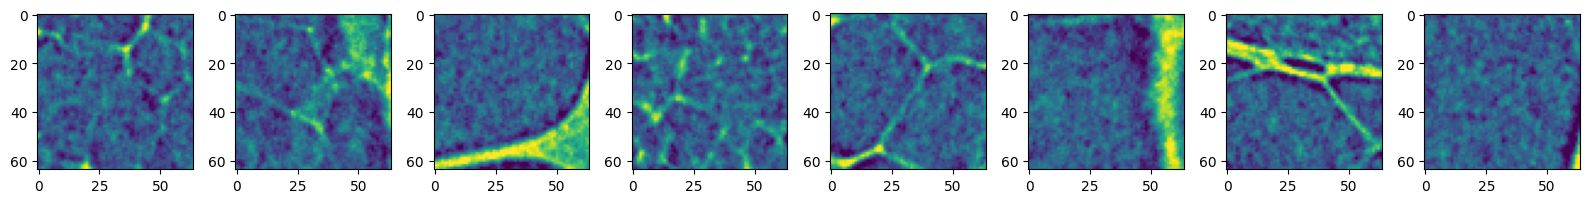

In [4]:
loader = DataLoader(
    ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,      # set 0 on Windows / if you hit HDF5 multiprocessing issues
    # pin_memory=True,
    drop_last=True,
    # persistent_workers=True,
)

# example
for x, meta in loader:
    print(x.shape)    # x: [B, 1, D, H, W]
    # meta["start_wdh"]: [B, 3]
    print(x.min(),x.max())
    print(x.dtype)

    fig, ax = plt.subplots(1,8,figsize = (16,4))

    for i in range(x.shape[0]):
        ax[i].imshow(x[i,0,0,::])
       
    fig.tight_layout()
    break
